# Load a trained AB-UPT / DrivAerML run in Python

This notebook shows the **interactive** counterpart to `noether-eval`: load a trained AB-UPT model and its dataset directly into Python, run a forward pass on a single sample, and inspect the predictions.

Use this when you want to:
- inspect what the model actually produces on individual samples,
- prototype a new visualization,
- apply a trained model to **your own data** (a CAD mesh, a custom point cloud — see section 6),
- compare predictions against ground truth without going through the trainer.

For reproducible eval (metrics, callbacks, logs, VTK export), use `noether-eval` or `python -m showcase.cli evaluate` instead.

**Requires `matplotlib`** for section 5's plots — install with `uv pip install matplotlib` if your environment doesn't have it.

<div class="alert alert-block alert-warning">
The numbers and plots shown here come from an AB-UPT model trained for only 2 epochs on DrivAerML - illustrative of the inference flow, not of the model's true accuracy.

We are not aiming here for high quality results, but to show the concepts of how to initialize and run inference in an interactive manner.
</div>

## Configure paths

Edit the two paths. `RUN_DIR` is the training run output directory (it contains `hp_resolved.yaml` and a `checkpoints/` subdirectory). `DATASET_ROOT` is where the DrivAerML data lives on **this** machine; if you don't already have it, the subsampled 10× copy used here is published at [huggingface.co/datasets/EmmiAI/DrivAerML_subsampled_10x](https://huggingface.co/datasets/EmmiAI/DrivAerML_subsampled_10x).

In [25]:
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader

# The loaded run config refers to recipe classes by dotted path (e.g. ``aero_cfd.datasets.drivaerml.DrivAerMLDataset``); ConfigSchema validation imports them,
# so the recipe's src must be importable. Walk up from cwd so this works whether Jupyter was launched from the repo root or from ``notebooks/``.
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / "recipes" / "aero_cfd" / "src").exists():
    _p = _p.parent
_aero_src = _p / "recipes" / "aero_cfd" / "src"
if _aero_src.exists() and str(_aero_src) not in sys.path:
    sys.path.insert(0, str(_aero_src))

from noether.inference import Run  # noqa: E402

RUN_DIR = Path("/path/to/outputs/<run_id>")  # contains hp_resolved.yaml + checkpoints/
DATASET_ROOT = Path("/path/to/drivaerml")  # local copy of the dataset (only for sections 2–5)
SPLIT = "test"
CHECKPOINT = "latest"  # adjust to match your run; common tags: "last", "latest", "best_model.loss.test.total", "E10"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Open the run and patch the config

`Run(run_dir)` reads `hp_resolved.yaml` and validates it; it doesn't load any weights or datasets yet. `run.config` is the same pydantic schema you'd see in a training script — mutate it in place to fix dataset roots (or anything else) before building the dataset/model.

In [26]:
run = Run(RUN_DIR)

# Point each split's dataset at the local data root.
for ds_cfg in run.config.datasets.values():
    ds_cfg.root = str(DATASET_ROOT)

print("run_id:", run.config.run_id)
print("model.name:", run.config.model.name)
print("splits:", list(run.config.datasets))

run_id: None
model.name: ab_upt
splits: ['train', 'val', 'test']


## 2. Build the dataset, the model, and the normalizers

`run.dataset(split)` instantiates the dataset and wires its collator the same way the trainer does, so it's ready to feed into a `DataLoader`. `run.model(...)` instantiates the model and loads weights from `RUN_DIR/checkpoints/`. `run.normalizers(split)` builds the field normalizers used to convert raw inputs into the units the model was trained on (and predictions back to physical units, in section 5). All three are lazy — calling them is what triggers the actual work.

**Note:** only `run.dataset()` needs the original data files. `run.model()` and `run.normalizers()` work without them — that's the basis for section 6.

In [27]:
dataset = run.dataset(SPLIT)
model = run.model(checkpoint=CHECKPOINT, device=DEVICE)
norms = run.normalizers(SPLIT)

print(f"{len(dataset)=}")
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"normalizers: {sorted(norms.keys())}")

len(dataset)=50
model parameters: 35,051,147
normalizers: ['surface_friction', 'surface_position', 'surface_pressure', 'volume_position', 'volume_pressure', 'volume_velocity', 'volume_vorticity']


## 3. Inspect one sample

Each item the dataset returns is a dict of tensors, already normalized by the pipeline. For AB-UPT on DrivAerML, the relevant keys are geometry positions, surface/volume anchor positions, and the corresponding target fields (surface pressure, volume velocity, etc.).

In [28]:
sample = dataset[0]
for k, v in sample.items():
    shape = tuple(v.shape) if hasattr(v, "shape") else type(v).__name__
    print(f"{k:40s}  {shape}")

volume_vorticity                          (13414253, 3)
surface_pressure                          (779271, 1)
surface_friction                          (779271, 3)
volume_velocity                           (13414253, 3)
volume_position                           (13414253, 3)
surface_normals                           (779271, 3)
index                                     int
volume_pressure                           (13414253, 1)
surface_position                          (779271, 3)
surface_area                              (779271,)


## 4. Forward pass through the model

Use a `DataLoader` of batch size 1 with the dataset's own collator — that handles all the batch-idx bookkeeping AB-UPT expects. The forward kwargs below are the AB-UPT-on-DrivAerML inputs (see `AeroCFDPreset.forward_properties_map` in `recipes/aero_cfd/src/aero_cfd/presets/base.py`).

In [29]:
AB_UPT_FORWARD_KEYS = [
    "geometry_position",
    "geometry_supernode_idx",
    "geometry_batch_idx",
    "surface_anchor_position",
    "volume_anchor_position",
]

loader = DataLoader(dataset, batch_size=1, collate_fn=dataset.pipeline)
batch = next(iter(loader))

missing = [k for k in AB_UPT_FORWARD_KEYS if k not in batch]
if missing:
    raise KeyError(f"batch missing expected AB-UPT keys: {missing}. Got: {sorted(batch)}")

inputs = {k: batch[k].to(DEVICE) for k in AB_UPT_FORWARD_KEYS}
with torch.inference_mode():
    pred = model(**inputs)

print("batch keys:", sorted(batch))
print({k: tuple(v.shape) for k, v in pred.items()})

batch keys: ['geometry_batch_idx', 'geometry_position', 'geometry_supernode_idx', 'index', 'surface_anchor_position', 'surface_area', 'surface_friction_target', 'surface_normals', 'surface_pressure_target', 'volume_anchor_position', 'volume_pressure_target', 'volume_velocity_target', 'volume_vorticity_target']
{'surface_pressure': (1, 2048, 1), 'surface_friction': (1, 2048, 3), 'volume_pressure': (1, 4096, 1), 'volume_velocity': (1, 4096, 3), 'volume_vorticity': (1, 4096, 3)}


## 5. Denormalize and visualize

Predictions come out in normalized units. Use the normalizers from section 2 - `norms[field].inverse(tensor)` is the inverse transform - to bring them back into physical space. AB-UPT predictions on DrivAerML are shaped `(B, N, C)` per field; with `batch_size=1` we take `[0]` to get a single sample.

Below we plot ground-truth vs predicted surface pressure as a 3D scatter. For ParaView-ready VTP files use `recipes/aero_cfd/showcase/utils/vtk_export.py:export_pointcloud_to_vtk` instead.

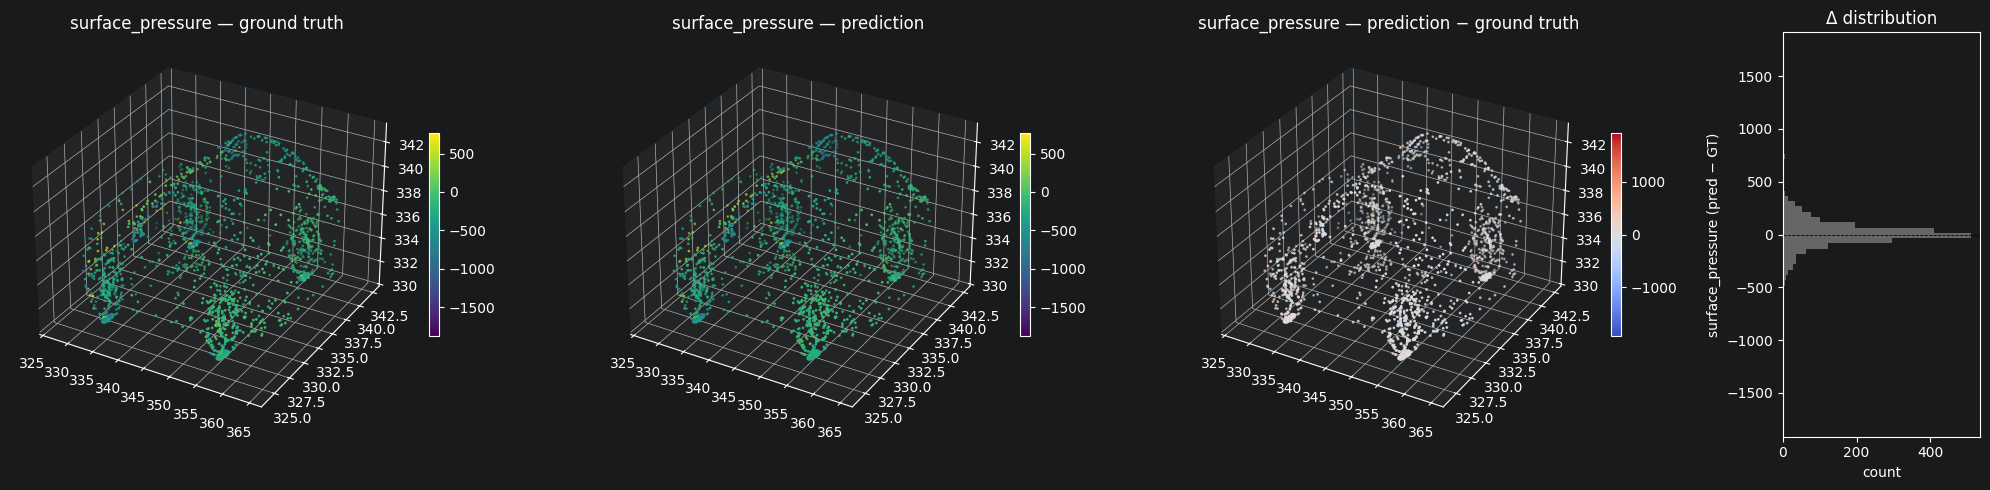

In [30]:
import matplotlib.pyplot as plt

field = "surface_pressure"  # change to e.g. "volume_velocity" to inspect the volume domain

pos = batch["surface_anchor_position"][0].cpu()  # (N, 3)
# AeroCFD pipeline convention: GT for a target field lives under "<field>_target"
# in the collated batch (see AeroMultistagePipeline._build_collator_pipeline); the
# model's prediction dict uses the un-suffixed name.
gt_phys = norms[field].inverse(batch[f"{field}_target"][0].cpu())  # (N, C)
pred_phys = norms[field].inverse(pred[field][0].cpu())  # (N, C)
diff = pred_phys - gt_phys  # signed error

# Share GT/pred scale so the visual comparison is fair; give diff its own
# diverging scale centered at 0.
shared_vmin = min(gt_phys.min().item(), pred_phys.min().item())
shared_vmax = max(gt_phys.max().item(), pred_phys.max().item())
diff_vmax = diff.abs().max().item()

panels = [
    ("ground truth", gt_phys, {"vmin": shared_vmin, "vmax": shared_vmax}),
    ("prediction", pred_phys, {"vmin": shared_vmin, "vmax": shared_vmax}),
    ("prediction − ground truth", diff, {"cmap": "coolwarm", "vmin": -diff_vmax, "vmax": diff_vmax}),
]

fig = plt.figure(figsize=(20, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[3, 3, 3, 1.2])
for i, (title, values, kwargs) in enumerate(panels):
    ax = fig.add_subplot(gs[0, i], projection="3d")
    sc = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=values.squeeze(-1), s=1, **kwargs)
    ax.set_title(f"{field} — {title}")
    fig.colorbar(sc, ax=ax, shrink=0.5)

# Histogram of the signed delta, on the same y-axis (and limits) as the diff
# colorbar - bars line up with the colors so you can read at a glance whether
# the bulk of the mass sits inside a tight band vs. spans the full range.
ax_hist = fig.add_subplot(gs[0, 3])
ax_hist.hist(diff.squeeze(-1).numpy(), bins=60, orientation="horizontal", color="0.4")
ax_hist.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax_hist.set_ylim(-diff_vmax, diff_vmax)
ax_hist.set_xlabel("count")
ax_hist.set_ylabel(f"{field} (pred − GT)")
ax_hist.set_title("Δ distribution")

plt.tight_layout()
plt.show()

## 6. Bring your own data

Sections 2–5 used `run.dataset(split)` to wire up noether's Dataset + Pipeline machinery. You don't actually need any of that to use a trained model — the model only knows about tensor inputs, and the normalizers only need numbers. `run.dataset()` is one convenient way to get those tensors; it's not the only way.

Below we read the raw `.pt` arrays directly off disk, do the geometry/anchor sampling manually (replicating what `AeroMultistagePipeline` does under the hood), normalize with `run.normalizers(...)`, and run a forward pass — finishing with a quick MAE vs raw GT at the same anchor points. Swap the file paths for any source you can load into torch tensors (a CAD mesh, a CFD-solver dump, a custom point cloud) and the rest of the flow is unchanged.

In [31]:
# A fresh Run with no dataset root configured — `run_byo.dataset(...)` would fail,
# but we never call it.
run_byo = Run(RUN_DIR)
model_byo = run_byo.model(checkpoint=CHECKPOINT, device=DEVICE)
norms_byo = run_byo.normalizers(SPLIT)

print("available normalizers:", sorted(norms_byo.keys()))
print("first few training-time stat keys:", sorted(run_byo.statistics.keys())[:8])

available normalizers: ['surface_friction', 'surface_position', 'surface_pressure', 'volume_position', 'volume_pressure', 'volume_velocity', 'volume_vorticity']
first few training-time stat keys: ['raw_pos_max', 'raw_pos_min', 'surface_friction_mean', 'surface_friction_std', 'surface_pressure_mean', 'surface_pressure_std', 'volume_pressure_mean', 'volume_pressure_std']


In [32]:
# 1. Read raw arrays straight from disk. DrivAerML ships one .pt per field per
#    sample (see noether.data.datasets.cfd.caeml.filemap.CAEML_FILEMAP for the
#    full mapping). Swap these paths for any source you can torch.load.
sample_dir = DATASET_ROOT / "run_1"
raw_surface_pos = torch.load(sample_dir / "surface_position_vtp.pt", weights_only=True)  # (N_surf, 3)
raw_volume_pos = torch.load(sample_dir / "volume_cell_position.pt", weights_only=True)  # (N_vol, 3)
raw_surface_pressure = torch.load(sample_dir / "surface_pressure.pt", weights_only=True)  # (N_surf,) — for MAE only
print(f"raw shapes: surface={tuple(raw_surface_pos.shape)}, volume={tuple(raw_volume_pos.shape)}")

# 2. Use the same sampling counts the training pipeline used — read straight
#    from the resolved config so you never have to hand-copy magic numbers.
pipe = run_byo.config.datasets[SPLIT].pipeline
N_geom = pipe.num_geometry_points
N_super = pipe.num_geometry_supernodes
N_surf_anchor = pipe.num_surface_anchor_points
N_vol_anchor = pipe.num_volume_anchor_points
print(
    f"sampling: geometry={N_geom}, supernodes={N_super}, surface_anchor={N_surf_anchor}, volume_anchor={N_vol_anchor}"
)

# 3. Sample positions. The training pipeline uses torch.randperm under the hood
#    (PointSamplingSampleProcessor, SupernodeSamplingSampleProcessor); do the
#    same here so the inputs land in the same statistical regime.
gen = torch.Generator().manual_seed(0)
geom_idx = torch.randperm(raw_surface_pos.shape[0], generator=gen)[:N_geom]
geom_pos = raw_surface_pos[geom_idx]  # (N_geom, 3)
supernode_idx = torch.randperm(N_geom, generator=gen)[:N_super]  # (N_super,) — indices into geom_pos
surf_anchor_idx = torch.randperm(raw_surface_pos.shape[0], generator=gen)[:N_surf_anchor]
vol_anchor_idx = torch.randperm(raw_volume_pos.shape[0], generator=gen)[:N_vol_anchor]
surf_anchor_pos = raw_surface_pos[surf_anchor_idx]  # (N_surf_anchor, 3)
vol_anchor_pos = raw_volume_pos[vol_anchor_idx]  # (N_vol_anchor, 3)

# 4. Normalize each position with its matching field normalizer and assemble the
#    forward-input dict. Single-sample batch → batch_idx is all zeros.
inputs_byo = {
    "geometry_position": norms_byo["surface_position"](geom_pos).to(DEVICE),
    "geometry_supernode_idx": supernode_idx.to(DEVICE),
    "geometry_batch_idx": torch.zeros(N_geom, dtype=torch.long, device=DEVICE),
    "surface_anchor_position": norms_byo["surface_position"](surf_anchor_pos).unsqueeze(0).to(DEVICE),
    "volume_anchor_position": norms_byo["volume_position"](vol_anchor_pos).unsqueeze(0).to(DEVICE),
}

with torch.inference_mode():
    pred_byo = model_byo(**inputs_byo)

# 5. Denormalize the prediction and compare against raw GT at the same anchor
#    indices. MAE is in physical units (Pa for surface_pressure).
pred_pressure = norms_byo["surface_pressure"].inverse(pred_byo["surface_pressure"][0].cpu())  # (N_surf_anchor, 1)
gt_pressure = raw_surface_pressure[surf_anchor_idx].unsqueeze(-1)  # (N_surf_anchor, 1)
mae = (pred_pressure - gt_pressure).abs().mean().item()
print(
    f"\npredicted surface_pressure: shape={tuple(pred_pressure.shape)}, "
    f"min={pred_pressure.min().item():.3f}, max={pred_pressure.max().item():.3f}"
)
print(f"MAE vs raw GT at the sampled anchor points: {mae:.3f}")

raw shapes: surface=(882809, 3), volume=(14744958, 3)
sampling: geometry=16384, supernodes=4096, surface_anchor=2048, volume_anchor=4096

predicted surface_pressure: shape=(2048, 1), min=-1367.605, max=646.331
MAE vs raw GT at the sampled anchor points: 95.670


### Visualize the BYO result

Same 3-panel layout (GT, prediction, signed delta) and Δ-distribution histogram as section 5, but sourced from the raw `.pt` arrays instead of the dataset pipeline. If the model and normalizers really are independent of the Dataset machinery, the BYO plot should be qualitatively similar to section 5's.

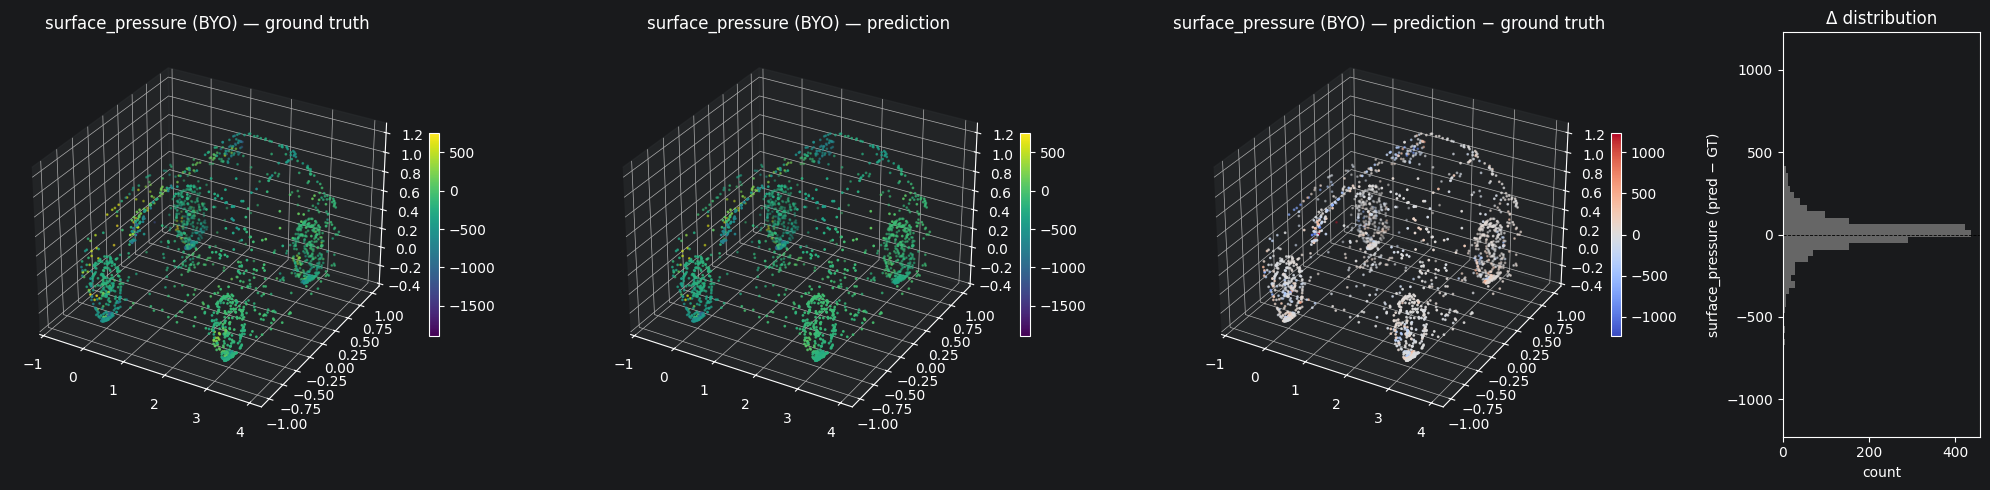

In [33]:
diff_byo = pred_pressure - gt_pressure
shared_vmin_b = min(gt_pressure.min().item(), pred_pressure.min().item())
shared_vmax_b = max(gt_pressure.max().item(), pred_pressure.max().item())
diff_vmax_b = diff_byo.abs().max().item()

panels_byo = [
    ("ground truth", gt_pressure, {"vmin": shared_vmin_b, "vmax": shared_vmax_b}),
    ("prediction", pred_pressure, {"vmin": shared_vmin_b, "vmax": shared_vmax_b}),
    ("prediction − ground truth", diff_byo, {"cmap": "coolwarm", "vmin": -diff_vmax_b, "vmax": diff_vmax_b}),
]

fig_byo = plt.figure(figsize=(20, 5))
gs_byo = fig_byo.add_gridspec(1, 4, width_ratios=[3, 3, 3, 1.2])
for i, (title, values, kwargs) in enumerate(panels_byo):
    ax = fig_byo.add_subplot(gs_byo[0, i], projection="3d")
    sc = ax.scatter(
        surf_anchor_pos[:, 0],
        surf_anchor_pos[:, 1],
        surf_anchor_pos[:, 2],
        c=values.squeeze(-1),
        s=1,
        **kwargs,
    )
    ax.set_title(f"surface_pressure (BYO) — {title}")
    fig_byo.colorbar(sc, ax=ax, shrink=0.5)

ax_hist_byo = fig_byo.add_subplot(gs_byo[0, 3])
ax_hist_byo.hist(diff_byo.squeeze(-1).numpy(), bins=60, orientation="horizontal", color="0.4")
ax_hist_byo.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax_hist_byo.set_ylim(-diff_vmax_b, diff_vmax_b)
ax_hist_byo.set_xlabel("count")
ax_hist_byo.set_ylabel("surface_pressure (pred − GT)")
ax_hist_byo.set_title("Δ distribution")

plt.tight_layout()
plt.show()

## Next steps

- **Reproducible eval** — `python -m showcase.cli evaluate --dataset-root <...> --output-path <...> --run-id <...>` runs the full pipeline (metrics, predictions, VTK export, force computation).
- **ParaView export** — `recipes/aero_cfd/showcase/utils/vtk_export.py:export_pointcloud_to_vtk` writes a VTP point cloud from the prediction dict.
- **A different recipe** — `Run` is recipe-agnostic. For models other than AB-UPT, swap `AB_UPT_FORWARD_KEYS` for the recipe's own `forward_properties_map` entry; everything else stays the same.